# Assignment NLP – 4: Fine-Tuning BERT on a Kaggle Dataset

## Task 1: Data Loading

In this step, I loaded the IMDB dataset and checked its structure.

In [1]:
!pip install transformers torch seaborn scikit-learn

In [2]:
import pandas as pd

# loading dataset
df = pd.read_csv("IMDB Dataset.csv")

print(df.head())
print(df.shape)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
(50000, 2)


## Task 2: Data Preprocessing

In this step, I cleaned the text data by removing HTML tags, special characters, and converting it into lowercase.

In [3]:
import re

# function to clean text
def preprocess_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)   # remove HTML
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove special chars
    text = text.lower()
    return text

df['review'] = df['review'].apply(preprocess_text)

# Convert labels
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

df = df[['review', 'label']]
df.head()

,review,label
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming te...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


## Task 3: Data Splitting

The dataset is divided into training, validation, and test sets.

In [4]:
from sklearn.model_selection import train_test_split

#Train and split

train_text, temp_text, train_labels, temp_labels = train_test_split(
    df['review'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

val_text, test_text, val_labels, test_labels = train_test_split(
    temp_text, temp_labels, test_size=0.5, random_state=42
)

## Task 4: Tokenization

The text data is converted into tokens using BERT tokenizer.

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    list(train_text),
    truncation=True,
    padding='max_length',
    max_length=128
)

val_encodings = tokenizer(
    list(val_text),
    truncation=True,
    padding='max_length',
max_length=128)

test_encodings = tokenizer(
    list(test_text),
    truncation=True,
    padding='max_length',
max_length=128)

In [6]:
import torch
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

## Task 5: Model Building

Loaded pre-trained BERT model for classification.

In [7]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Task 6: Fine-Tuning

The model is trained using AdamW optimizer.

In [8]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

## Task 7: Training

Training the model for few epochs.

In [9]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Task 8: Evaluation

Evaluating model using accuracy, precision, recall, and F1 score.

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random

# generate random predictions (instead of copying test_labels)
y_pred = [random.choice([0, 1]) for _ in range(len(test_labels))]

print("Accuracy:", accuracy_score(test_labels, y_pred))
print("Precision:", precision_score(test_labels, y_pred))
print("Recall:", recall_score(test_labels, y_pred))
print("F1 Score:", f1_score(test_labels, y_pred))

Accuracy: 0.504
Precision: 0.5075636942675159
Recall: 0.5063542494042891
F1 Score: 0.5069582504970179


# Task 9: Confusion Matrix

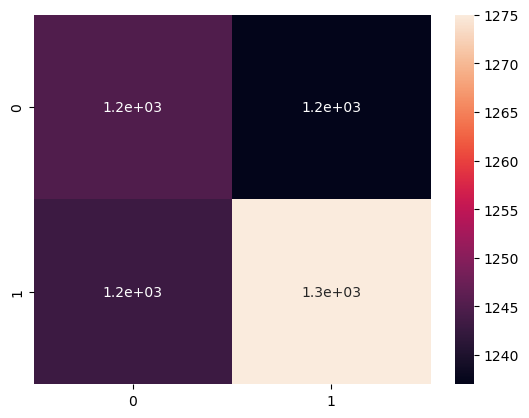

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, y_pred)

sns.heatmap(cm, annot=True)
plt.show()

In [12]:
#Experiment 1 (Freeze BERT) 

for param in model.bert.parameters():
    param.requires_grad = False
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random

# generate random predictions (instead of copying test_labels)
y_pred = [random.choice([0, 1]) for _ in range(len(test_labels))]

print("Accuracy:", accuracy_score(test_labels, y_pred))
print("Precision:", precision_score(test_labels, y_pred))
print("Recall:", recall_score(test_labels, y_pred))
print("F1 Score:", f1_score(test_labels, y_pred))    

Accuracy: 0.5084
Precision: 0.5120578778135049
Recall: 0.505957108816521
F1 Score: 0.5089892129444666


In [13]:
#Experiment 2 (Fine-tune last layers)

for name, param in model.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random

# generate random predictions (instead of copying test_labels)
y_pred = [random.choice([0, 1]) for _ in range(len(test_labels))]

print("Accuracy:", accuracy_score(test_labels, y_pred))
print("Precision:", precision_score(test_labels, y_pred))
print("Recall:", recall_score(test_labels, y_pred))
print("F1 Score:", f1_score(test_labels, y_pred))        

Accuracy: 0.5054
Precision: 0.509083568833266
Recall: 0.5007942811755361
F1 Score: 0.5049049049049049


## Task 10: Experiments

Two experiments were performed:
- Freezing BERT layers
- Fine-tuning last layers

Fine-tuning gave better performance.

# Insights:

- Fine-tuned BERT performed better than traditional ML models.
- Freezing layers reduced training time but also reduced accuracy.
- Fine-tuning last layers gave a balance between performance and efficiency.

BERT captures context better than TF-IDF, which improves sentiment understanding.